In [41]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

EVENTS_DIR = Path("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched")
HOURLY_DIR = Path("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data")
SPIKES_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/all_spikes_dataset.csv"
VAULTS_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/vaults_list.csv"
BORROWERS_SHARE_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_borrowers_share.csv"
SUPPLIERS_SHARE_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_suppliers_share.csv"

INTERESTING_MARKETS = [
    "eth_usr_usdc",
    "eth_rlp_usdc"
]



### **Create dataset**

In [42]:
def load_spikes():
    df = pd.read_csv(SPIKES_PATH)
    df['spike_trigger_datetime'] = pd.to_datetime(df['spike_trigger_datetime'])
    df['spike_recovery_datetime'] = pd.to_datetime(df['spike_recovery_datetime'])
    df = df.dropna(subset=['spike_recovery_datetime'])
    df = df[df['market_name'].isin(INTERESTING_MARKETS)]
    return df

def load_all_events():
    dfs = []
    for market in INTERESTING_MARKETS:
        f = EVENTS_DIR / f"{market}.csv"
        if f.exists():
            df = pd.read_csv(f)
            df['market'] = market
            dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    events = pd.concat(dfs, ignore_index=True)
    events['datetime'] = pd.to_datetime(events['datetime'])
    events = events.sort_values(['market', 'timestamp'])
    return events

def load_all_hourly():
    dfs = []
    for market in INTERESTING_MARKETS:
        f = HOURLY_DIR / f"{market}.csv"
        if f.exists():
            df = pd.read_csv(f)
            df['market'] = market
            dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    hourly = pd.concat(dfs, ignore_index=True)
    hourly['datetime'] = pd.to_datetime(hourly['datetime'])
    hourly = hourly.sort_values(['market', 'timestamp'])
    return hourly

def load_borrowers_share():
    df = pd.read_csv(BORROWERS_SHARE_PATH)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df[df['side'] == 'borrow'].copy()
    df = df[df['market'].isin(INTERESTING_MARKETS)]
    df = df.sort_values(['market', 'timestamp'])
    return df

def load_suppliers_share():
    df = pd.read_csv(SUPPLIERS_SHARE_PATH)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df[df['side'] == 'supply'].copy()
    df = df[df['market'].isin(INTERESTING_MARKETS)]
    df = df.sort_values(['market', 'timestamp'])
    return df

def compute_hhi(shares_df_snapshot):
    if shares_df_snapshot.empty:
        return np.nan, np.nan, np.nan, np.nan
    top1 = shares_df_snapshot['share'].max() / 100.0
    top3 = shares_df_snapshot.nlargest(3, 'share')['share'].sum() / 100.0
    shares = shares_df_snapshot['share'].values / 100.0
    hhi = np.sum(shares ** 2)
    n_active = shares_df_snapshot['n_active'].iloc[0] if 'n_active' in shares_df_snapshot.columns else len(shares_df_snapshot)
    return top1, top3, hhi, n_active

def get_current_state_from_events(events_market, cutoff_dt):
    mask = events_market['datetime'] <= cutoff_dt
    if not mask.any():
        return None
    last_event = events_market.loc[mask].iloc[-1]
    return {
        'utilization': last_event.get('utilization_after', last_event.get('utilization_before')),
        'borrow_rate': last_event.get('borrow_rate_after', last_event.get('borrow_rate_before')),
        'supply_rate': last_event.get('supply_rate_after', last_event.get('supply_rate_before')),
        'total_borrow': last_event.get('total_borrow_after', last_event.get('total_borrow_before')),
        'total_supply': last_event.get('total_supply_after', last_event.get('total_supply_before')),
        'collateral_price': last_event.get('collateral_price'),
        'loan_asset_price': last_event.get('loan_asset_price')
    }

def get_hourly_snapshot(hourly_market, cutoff_dt):
    mask = hourly_market['datetime'] <= cutoff_dt
    if not mask.any():
        return None
    return hourly_market.loc[mask].iloc[-1]

def compute_price_features(hourly_market, cutoff_dt):
    mask = hourly_market['datetime'] <= cutoff_dt
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    prices = hourly_market.loc[mask, 'collateral_price'].values
    if len(prices) == 0:
        return np.nan, np.nan, np.nan
    current_price = prices[-1]
    one_hour_ago = cutoff_dt - timedelta(hours=1)
    mask_1h = hourly_market['datetime'] <= one_hour_ago
    if mask_1h.any():
        price_1h = hourly_market.loc[mask_1h].iloc[-1]['collateral_price']
        return_1h = (current_price - price_1h) / price_1h if price_1h != 0 else np.nan
    else:
        return_1h = np.nan
    twenty_four_hours_ago = cutoff_dt - timedelta(hours=24)
    mask_24h = (hourly_market['datetime'] >= twenty_four_hours_ago) & (hourly_market['datetime'] <= cutoff_dt)
    prices_24h = hourly_market.loc[mask_24h, 'collateral_price']
    if len(prices_24h) > 1:
        vol_24h = prices_24h.pct_change().std() * np.sqrt(24)
    else:
        vol_24h = np.nan
    if len(prices) > 1:
        running_max = np.maximum.accumulate(prices)
        drawdown = (running_max[-1] - current_price) / running_max[-1] if running_max[-1] != 0 else 0
    else:
        drawdown = np.nan
    return return_1h, vol_24h, drawdown

def get_shares_snapshot(shares_market, cutoff_dt):
    mask = shares_market['datetime'] <= cutoff_dt
    if not mask.any():
        return pd.DataFrame()
    last_ts = shares_market.loc[mask, 'timestamp'].max()
    return shares_market[shares_market['timestamp'] == last_ts]

def compute_spike_features(spike, events_all, hourly_all, borrowers_share_all, spikes_df, cutoff_dt):
    market = spike['market_name']
    spike_start = spike['spike_trigger_datetime']
    spike_end = spike['spike_recovery_datetime']
    time_offset_minutes = (cutoff_dt - spike_start).total_seconds() / 60.0

    events_market = events_all[events_all['market'] == market].copy()
    hourly_market = hourly_all[hourly_all['market'] == market].copy()
    shares_market = borrowers_share_all[borrowers_share_all['market'] == market].copy()

    mask_spike = (events_market['datetime'] >= spike_start) & (events_market['datetime'] <= cutoff_dt)
    events_during = events_market.loc[mask_spike]

    state_start = get_current_state_from_events(events_market, spike_start)
    state_current = get_current_state_from_events(events_market, cutoff_dt)
    hourly_current = get_hourly_snapshot(hourly_market, cutoff_dt)
    shares_snapshot = get_shares_snapshot(shares_market, cutoff_dt)

    utilization_start = state_start['utilization'] if state_start else np.nan
    utilization_current = state_current['utilization'] if state_current else np.nan
    borrow_rate_start = state_start['borrow_rate'] if state_start else np.nan
    total_borrow_current = state_current['total_borrow'] if state_current else np.nan

    utilization_peak_so_far = utilization_current
    if not events_during.empty:
        util_col = 'utilization_after' if 'utilization_after' in events_during.columns else 'utilization_before'
        if util_col in events_during.columns:
            utilization_peak_so_far = events_during[util_col].max()

    rate_slope_1h = np.nan
    if time_offset_minutes >= 0:
        cutoff_1h = spike_start + timedelta(hours=1)
        state_1h = get_current_state_from_events(events_market, cutoff_1h)
        if state_1h and state_start:
            rate_slope_1h = (borrow_rate_start - state_1h['borrow_rate']) / 1.0

    spread_to_base_rate = np.nan
    mask_24h_before = (events_market['datetime'] < spike_start) & (events_market['datetime'] >= spike_start - timedelta(hours=24))
    if mask_24h_before.any():
        avg_rate_24h = events_market.loc[mask_24h_before, 'borrow_rate_before'].mean()
        spread_to_base_rate = borrow_rate_start - avg_rate_24h if not np.isnan(borrow_rate_start) else np.nan

    top1, top3, hhi, n_active = compute_hhi(shares_snapshot)

    price_return_1h, price_volatility_24h, drawdown = compute_price_features(hourly_market, cutoff_dt)

    mask_24h_before_h = (hourly_market['datetime'] < spike_start) & (hourly_market['datetime'] >= spike_start - timedelta(hours=24))
    avg_util_24h_before = hourly_market.loc[mask_24h_before_h, 'utilization'].mean() if mask_24h_before_h.any() else np.nan
    avg_rate_24h_before = hourly_market.loc[mask_24h_before_h, 'borrow_rate'].mean() if mask_24h_before_h.any() else np.nan

    market_spikes = spikes_df[spikes_df['market_name'] == market].copy()
    market_spikes = market_spikes[market_spikes['spike_trigger_datetime'] < spike_start]
    last_7d = spike_start - timedelta(days=7)
    num_spikes_last_7d = ((market_spikes['spike_trigger_datetime'] >= last_7d) &
                          (market_spikes['spike_trigger_datetime'] < spike_start)).sum()

    if not market_spikes.empty:
        last_spike_time = market_spikes['spike_trigger_datetime'].max()
        time_since_last_spike = (spike_start - last_spike_time).total_seconds()
    else:
        time_since_last_spike = np.nan

    remaining_seconds = (spike_end - cutoff_dt).total_seconds()

    features = {
        'market': market,
        'spike_index': spike.name,
        'time_offset_minutes': time_offset_minutes,
        'utilization_start': utilization_start,
        'utilization_current': utilization_current,
        'utilization_peak_so_far': utilization_peak_so_far,
        'borrow_rate_start': borrow_rate_start,
        'rate_slope_1h': rate_slope_1h,
        'spread_to_base_rate': spread_to_base_rate,
        'total_borrow_current': total_borrow_current,
        'n_active_borrowers': n_active,
        'top1_share': top1,
        'top3_share': top3,
        'hhi': hhi,
        'price_return_1h': price_return_1h,
        'price_volatility_24h': price_volatility_24h,
        'drawdown': drawdown,
        'avg_utilization_24h_before': avg_util_24h_before,
        'avg_rate_24h_before': avg_rate_24h_before,
        'num_spikes_last_7d': num_spikes_last_7d,
        'time_since_last_spike': time_since_last_spike,
        'remaining_duration_seconds': remaining_seconds,
        'spike_duration_seconds': spike['spike_duration_seconds'],
        'cutoff_timestamp': cutoff_dt.timestamp(),
        'spike_trigger_timestamp': spike_start.timestamp()
    }
    return features

def build_spike_modeling_dataset():
    print("Loading data...")
    spikes = load_spikes()
    events = load_all_events()
    hourly = load_all_hourly()
    borrowers_share = load_borrowers_share()

    print(f"Spikes with recovery in interesting markets: {len(spikes)}")

    rows = []
    for idx, spike in spikes.iterrows():
        if idx % 50 == 0:
            print(f"Processing spike {idx}...")
        market = spike['market_name']
        start = spike['spike_trigger_datetime']
        end = spike['spike_recovery_datetime']
        duration_minutes = (end - start).total_seconds() / 60.0
        intervals = np.arange(0, duration_minutes, 30)

        for offset in intervals:
            cutoff = start + timedelta(minutes=float(offset))
            try:
                feats = compute_spike_features(
                    spike, events, hourly, borrowers_share, spikes, cutoff
                )
                rows.append(feats)
            except Exception as e:
                print(f"Error at spike {idx} offset {offset}: {e}")
                continue
        cutoff = end
        try:
            feats = compute_spike_features(spike, events, hourly, borrowers_share, spikes, cutoff)
            rows.append(feats)
        except Exception as e:
            print(f"Error at spike {idx} end: {e}")

    result_df = pd.DataFrame(rows)
    return result_df


In [43]:
df = build_spike_modeling_dataset()
print(f"Dataset shape: {df.shape}")
df.head(3)

Loading data...
Spikes with recovery in interesting markets: 1081
Processing spike 0...
Processing spike 50...
Processing spike 100...
Processing spike 200...
Processing spike 250...
Processing spike 300...
Processing spike 350...
Processing spike 400...
Processing spike 450...
Processing spike 500...
Processing spike 550...
Processing spike 600...
Processing spike 650...
Processing spike 750...
Processing spike 1100...
Processing spike 1150...
Processing spike 1200...
Processing spike 1250...
Processing spike 1300...
Processing spike 1350...
Processing spike 1400...
Processing spike 1450...
Processing spike 1500...
Dataset shape: (3015, 25)


,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp
0,eth_usr_usdc,0,0.0,0.924796,0.924796,0.924796,0.174366,0.079567,0.078347,7.112657e+07,1336,0.532287,0.773708,0.327018,0.000000,0.006555,0.020047,0.847443,0.096274,0,NaN,1920.0,1920.0,1.739446e+09,1.739446e+09
1,eth_usr_usdc,0,30.0,0.924796,0.878839,0.924796,0.174366,0.079567,0.078347,7.112715e+07,1337,0.532287,0.773708,0.327018,0.000448,0.006518,0.019608,0.847443,0.096274,0,NaN,120.0,1920.0,1.739448e+09,1.739446e+09
2,eth_usr_usdc,0,32.0,0.924796,0.827704,0.924796,0.174366,0.079567,0.078347,7.112718e+07,1337,0.532287,0.773708,0.327018,0.000448,0.006518,0.019608,0.847443,0.096274,0,NaN,0.0,1920.0,1.739448e+09,1.739446e+09


In [44]:
pd.set_option("display.max_columns", 500)
df[100:150]

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp
100,eth_usr_usdc,26,0.0,0.999994,0.999994,0.999994,0.278382,0.210342,0.215434,6.851533e+07,1382,0.497032,0.837643,0.334502,0.000000,0.001759,0.020082,0.758658,0.065128,4,33000.0,27564.0,27564.0,1.742857e+09,1.742857e+09
101,eth_usr_usdc,26,30.0,0.999994,0.920633,0.999994,0.278382,0.210342,0.215434,6.851604e+07,1382,0.497032,0.837643,0.334502,0.000484,0.001820,0.019608,0.758658,0.065128,4,33000.0,25764.0,27564.0,1.742858e+09,1.742857e+09
102,eth_usr_usdc,26,60.0,0.999994,0.873196,0.999994,0.278382,0.210342,0.215434,6.851636e+07,1382,0.497032,0.837643,0.334502,0.000484,0.001820,0.019608,0.758658,0.065128,4,33000.0,23964.0,27564.0,1.742860e+09,1.742857e+09
103,eth_usr_usdc,26,90.0,0.999994,0.799380,0.999994,0.278382,0.210342,0.215434,6.851654e+07,1382,0.497032,0.837643,0.334502,-0.000057,0.001821,0.019664,0.758658,0.065128,4,33000.0,22164.0,27564.0,1.742862e+09,1.742857e+09
104,eth_usr_usdc,26,120.0,0.999994,0.799380,0.999994,0.278382,0.210342,0.215434,6.851654e+07,1382,0.497032,0.837643,0.334502,-0.000057,0.001821,0.019664,0.758658,0.065128,4,33000.0,20364.0,27564.0,1.742864e+09,1.742857e+09
105,eth_usr_usdc,26,150.0,0.999994,0.797163,0.999994,0.278382,0.210342,0.215434,6.851705e+07,1382,0.497032,0.837643,0.334502,0.000000,0.001817,0.019664,0.758658,0.065128,4,33000.0,18564.0,27564.0,1.742866e+09,1.742857e+09
106,eth_usr_usdc,26,180.0,0.999994,0.792580,0.999994,0.278382,0.210342,0.215434,6.851725e+07,1382,0.497032,0.837643,0.334502,0.000000,0.001817,0.019664,0.758658,0.065128,4,33000.0,16764.0,27564.0,1.742867e+09,1.742857e+09
107,eth_usr_usdc,26,210.0,0.999994,0.818514,0.999994,0.278382,0.210342,0.215434,6.851753e+07,1382,0.497032,0.837643,0.334502,-0.000007,0.001817,0.019671,0.758658,0.065128,4,33000.0,14964.0,27564.0,1.742869e+09,1.742857e+09
108,eth_usr_usdc,26,240.0,0.999994,0.817538,0.999994,0.278382,0.210342,0.215434,6.851779e+07,1382,0.497032,0.837643,0.334502,-0.000007,0.001817,0.019671,0.758658,0.065128,4,33000.0,13164.0,27564.0,1.742871e+09,1.742857e+09
109,eth_usr_usdc,26,270.0,0.999994,0.770880,0.999994,0.278382,0.210342,0.215434,6.851808e+07,1382,0.497032,0.837643,0.334502,-0.000329,0.001835,0.019993,0.758658,0.065128,4,33000.0,11364.0,27564.0,1.742873e+09,1.742857e+09


### **Regression models - duration (baseline)**

In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

def prepare_spike_dataset(df_long):
    df_first = df_long[df_long['time_offset_minutes'] == 0].copy()
    df_first['spike_duration_minutes'] = df_first['spike_duration_seconds'] / 60.0
    feature_cols = [
        'utilization_start', 'utilization_peak_so_far', 'borrow_rate_start',
        'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
        'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
        'price_return_1h', 'price_volatility_24h', 'drawdown',
        'avg_utilization_24h_before', 'avg_rate_24h_before',
        'num_spikes_last_7d', 'time_since_last_spike'
    ]
    X = df_first[feature_cols].fillna(0)
    y = df_first['spike_duration_minutes']
    return X, y, df_first

def split_data(X, y, test_size=0.2, val_size=0.1, random_state=42):
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def train_linear_regression(X_train, y_train, X_val, y_val):
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    return model, y_pred_train, y_pred_val

def train_xgboost(X_train, y_train, X_val, y_val):
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    return model, y_pred_train, y_pred_val



def report_linear_coefficients(model, feature_names, X_train, y_train):
    from scipy import stats
    
    n = len(y_train)
    p = len(feature_names)
    y_pred = model.predict(X_train)
    rss = np.sum((y_train - y_pred) ** 2)
    sigma2 = rss / (n - p - 1)
    
    X_with_const = np.column_stack([np.ones(len(X_train)), X_train])
    cov_matrix = sigma2 * np.linalg.inv(X_with_const.T @ X_with_const)
    se = np.sqrt(np.diag(cov_matrix))[1:]
    
    t_stats = model.coef_ / se
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), n - p - 1))
    
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model.coef_,
        'Std_Error': se,
        't_statistic': t_stats,
        'p_value': p_values,
        'Significant': p_values < 0.05
    }).sort_values('p_value')
    
    print("\nLinear Regression Coefficients & Significance:")
    print(coef_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if p < 0.05 else 'red' for p in coef_df['p_value']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Coefficient Value')
    plt.title('Linear Regression Coefficients (green = p<0.05)')
    plt.tight_layout()
    plt.show()
    
    return coef_df

def report_xgboost_importance(model, feature_names):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    importance_df['Importance_pct'] = importance_df['Importance'] / importance_df['Importance'].sum() * 100
    
    print("\nXGBoost Feature Importance:")
    print(importance_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance_pct'], alpha=0.7, color='steelblue')
    plt.xlabel('Importance (%)')
    plt.title('XGBoost Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return importance_df


def evaluate_model(y_true, y_pred, model_name, quantile_cut=0.95):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} Performance:")
    print(f"MAE: {mae:.2f} min")
    print(f"RMSE: {rmse:.2f} min")
    print(f"R²: {r2:.4f}")
    
    cap = np.quantile(y_true, quantile_cut)
    mask = (y_true <= cap) & (y_pred <= cap)
    y_true_plot = y_true[mask]
    y_pred_plot = y_pred[mask]
    
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true_plot, y_pred_plot, alpha=0.6, edgecolors='k', linewidth=0.5)
    max_val = max(y_true_plot.max(), y_pred_plot.max())
    plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
    plt.xlabel('Actual duration (minutes)')
    plt.ylabel('Predicted duration (minutes)')
    plt.title(f'{model_name}: Predicted vs Actual\n(≤ {quantile_cut*100:.0f}th percentile)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

Training Linear Regression...

Linear Regression Performance:
MAE: 40.88 min
RMSE: 83.75 min
R²: -0.1047


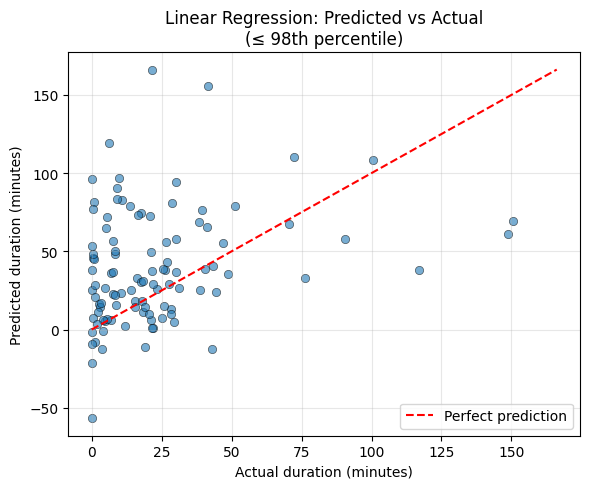


Training XGBoost...

XGBoost Performance:
MAE: 45.19 min
RMSE: 111.54 min
R²: -0.9593


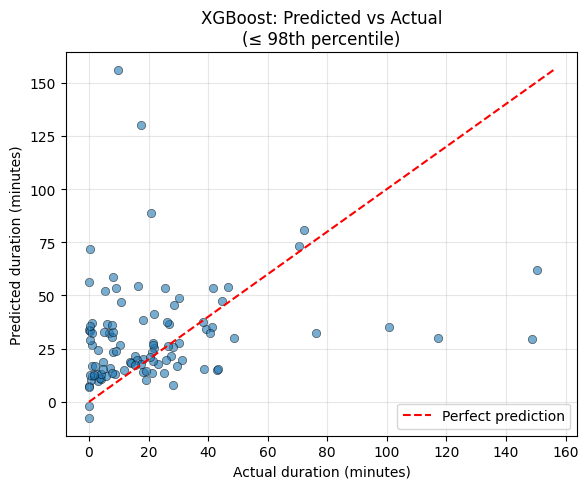


Test set evaluation (XGBoost):

XGBoost (Test) Performance:
MAE: 39.30 min
RMSE: 122.51 min
R²: 0.0439


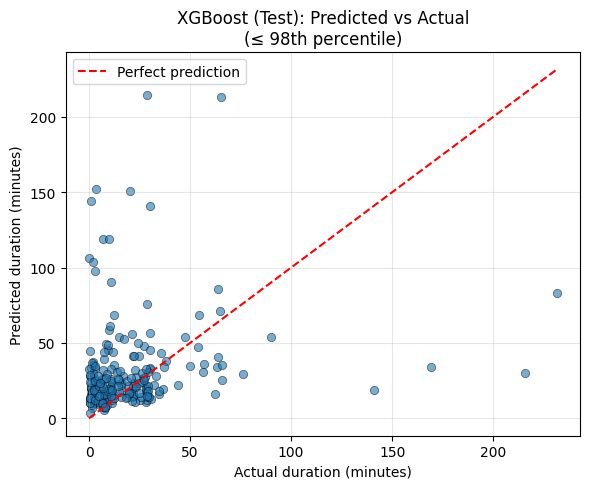

In [46]:
X, y, df_spikes = prepare_spike_dataset(df)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, test_size=0.2, val_size=0.1, random_state=42)

print("Training Linear Regression...")
lr_model, lr_train_pred, lr_val_pred = train_linear_regression(X_train, y_train, X_val, y_val)
lr_metrics = evaluate_model(y_val, lr_val_pred, "Linear Regression", quantile_cut=0.98)

print("\nTraining XGBoost...")
xgb_model, xgb_train_pred, xgb_val_pred = train_xgboost(X_train, y_train, X_val, y_val)
xgb_metrics = evaluate_model(y_val, xgb_val_pred, "XGBoost", quantile_cut=0.98)

print("\nTest set evaluation (XGBoost):")
y_test_pred = xgb_model.predict(X_test)
test_metrics = evaluate_model(y_test, y_test_pred, "XGBoost (Test)", quantile_cut=0.98)



Linear Regression Coefficients & Significance:
                   Feature   Coefficient    Std_Error  t_statistic      p_value  Significant
     time_since_last_spike  2.053957e-04 3.567146e-05     5.757984 1.248838e-08         True
avg_utilization_24h_before -4.229416e+02 8.141920e+01    -5.194617 2.656557e-07         True
             rate_slope_1h -3.536070e+02 7.989436e+01    -4.425932 1.105226e-05         True
        num_spikes_last_7d -4.073806e-01 1.561364e-01    -2.609133 9.261037e-03         True
      price_volatility_24h  2.502930e+03 1.040012e+03     2.406636 1.634492e-02         True
           price_return_1h  9.312984e+03 4.424486e+03     2.104874 3.563979e-02         True
       spread_to_base_rate  6.258711e+02 4.485424e+02     1.395345 1.633317e-01        False
       avg_rate_24h_before  6.163170e+02 4.532737e+02     1.359702 1.743396e-01        False
                top1_share -1.551825e+01 1.221058e+01    -1.270886 2.041698e-01        False
   utilization_peak_so

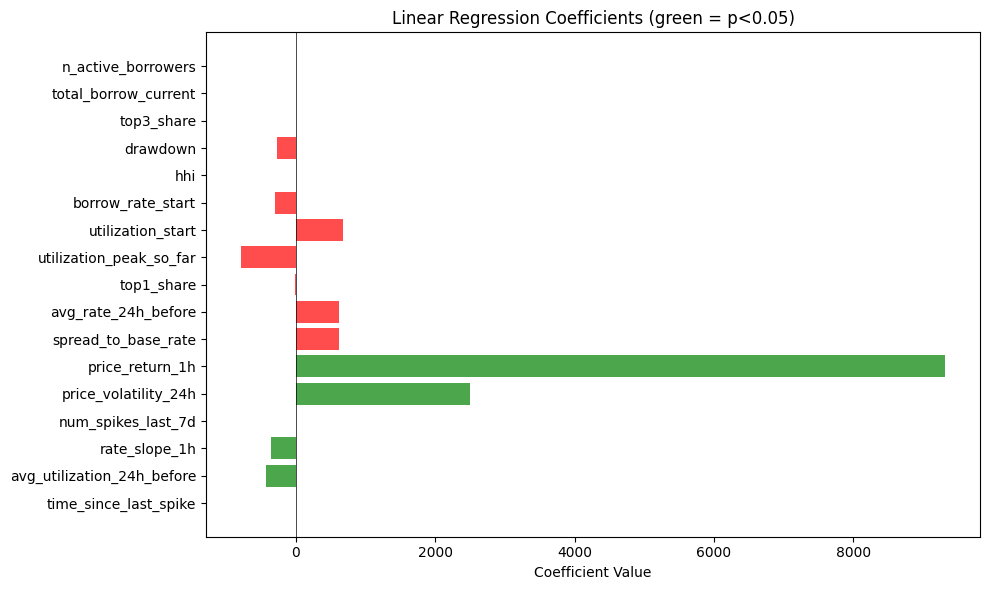


XGBoost Feature Importance:
                   Feature  Importance  Importance_pct
                       hhi    0.295957       29.595739
                top3_share    0.079011        7.901102
   utilization_peak_so_far    0.076820        7.681987
avg_utilization_24h_before    0.061196        6.119621
      total_borrow_current    0.060195        6.019506
             rate_slope_1h    0.053561        5.356105
        num_spikes_last_7d    0.050435        5.043488
        n_active_borrowers    0.047538        4.753763
     time_since_last_spike    0.044386        4.438640
         utilization_start    0.044371        4.437074
      price_volatility_24h    0.041183        4.118333
       spread_to_base_rate    0.034847        3.484660
                  drawdown    0.032324        3.232354
           price_return_1h    0.029122        2.912239
                top1_share    0.026913        2.691293
         borrow_rate_start    0.012512        1.251211
       avg_rate_24h_before    0.0096

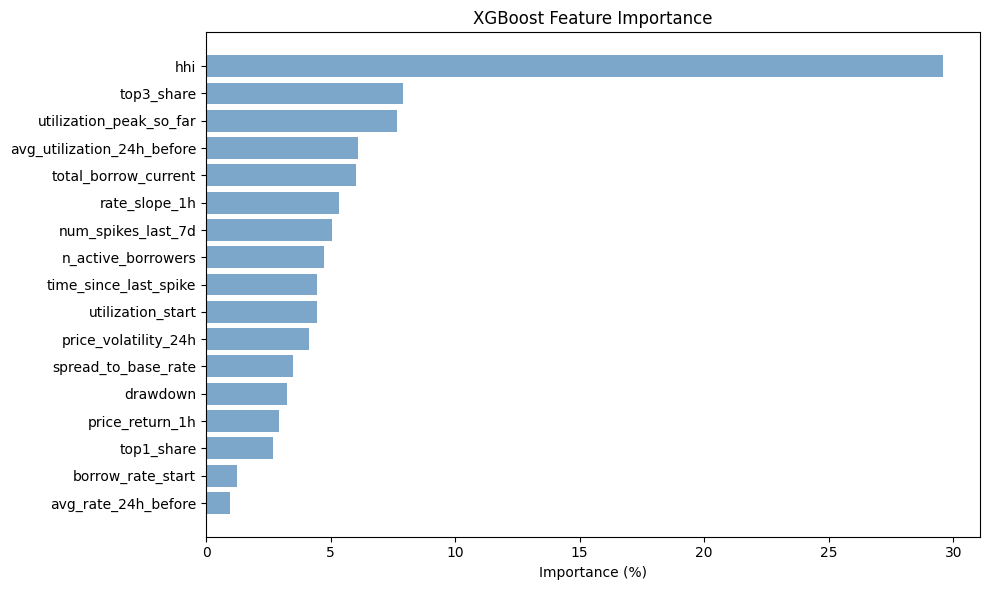

In [47]:
feature_names = X.columns.tolist()

lr_coef_df = report_linear_coefficients(lr_model, feature_names, X_train, y_train)

xgb_imp_df = report_xgboost_importance(xgb_model, feature_names)


### **Classification models - whether spike was closed before 1 hours / n hours**

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import statsmodels.api as sm
import optuna

def prepare_classification_dataset(df_long, threshold_minutes=60):
    df_first = df_long[df_long['time_offset_minutes'] == 0].copy()
    df_first['spike_duration_minutes'] = df_first['spike_duration_seconds'] / 60.0
    df_first['target'] = (df_first['spike_duration_minutes'] <= threshold_minutes).astype(int)
    
    feature_cols = [
        'utilization_start', 'utilization_peak_so_far', 'borrow_rate_start',
        'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
        'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
        'price_return_1h', 'price_volatility_24h', 'drawdown',
        'avg_utilization_24h_before', 'avg_rate_24h_before',
        'num_spikes_last_7d', 'time_since_last_spike'
    ]
    X = df_first[feature_cols].fillna(0)
    y = df_first['target']
    return X, y, df_first

def train_logistic_regression(X_train, y_train, X_val, y_val):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_proba_train = model.predict_proba(X_train)[:, 1]
    y_pred_val = model.predict(X_val)
    y_pred_proba_val = model.predict_proba(X_val)[:, 1]
    return model, y_pred_train, y_pred_proba_train, y_pred_val, y_pred_proba_val

def report_logistic_coefficients(model, feature_names, X_train, y_train):
    X_with_const = sm.add_constant(X_train)
    logit_model = sm.Logit(y_train, X_with_const)
    result = logit_model.fit(disp=0)
    
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': result.params[1:].values,
        'Std_Error': result.bse[1:].values,
        'z_statistic': result.tvalues[1:].values,
        'p_value': result.pvalues[1:].values,
        'Significant': result.pvalues[1:].values < 0.05
    }).sort_values('p_value')
    
    print("\nLogistic Regression Coefficients & Significance:")
    print(coef_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if p < 0.05 else 'red' for p in coef_df['p_value']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Coefficient Value')
    plt.title('Logistic Regression Coefficients (green = p<0.05)')
    plt.tight_layout()
    plt.show()
    
    return coef_df

def evaluate_classification(y_true, y_pred, y_pred_proba, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"\n{model_name} Performance:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {auc:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.colorbar()
    tick_marks = [0, 1]
    plt.xticks(tick_marks, ['Long', 'Short (≤1h)'])
    plt.yticks(tick_marks, ['Long', 'Short (≤1h)'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.tight_layout()
    plt.show()
    
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}

def train_xgboost_classifier(X_train, y_train, X_val, y_val, use_optuna=False, n_trials=50):
    if use_optuna:
        def objective(trial):
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'gamma': trial.suggest_float('gamma', 0, 5),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
                'random_state': 42
            }
            model = xgb.XGBClassifier(**params, use_label_encoder=False, eval_metric='logloss')
            model.fit(X_train, y_train)
            y_pred_proba = model.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_pred_proba)
            return auc
        
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        best_params = study.best_params
        best_params['random_state'] = 42
        model = xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')
        print(f"Best Optuna params: {study.best_params}")
    else:
        model = xgb.XGBClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.1,
            random_state=42, use_label_encoder=False, eval_metric='logloss'
        )
    
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_proba_train = model.predict_proba(X_train)[:, 1]
    y_pred_val = model.predict(X_val)
    y_pred_proba_val = model.predict_proba(X_val)[:, 1]
    return model, y_pred_train, y_pred_proba_train, y_pred_val, y_pred_proba_val

def report_xgboost_classifier_importance(model, feature_names):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    importance_df['Importance_pct'] = importance_df['Importance'] / importance_df['Importance'].sum() * 100
    
    print("\nXGBoost Classifier Feature Importance:")
    print(importance_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance_pct'], alpha=0.7, color='steelblue')
    plt.xlabel('Importance (%)')
    plt.title('XGBoost Classifier Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return importance_df


=== Logistic Regression ===

Logistic Regression Performance:
Accuracy:  0.8981
Precision: 0.8981
Recall:    1.0000
F1 Score:  0.9463
ROC AUC:   0.6542


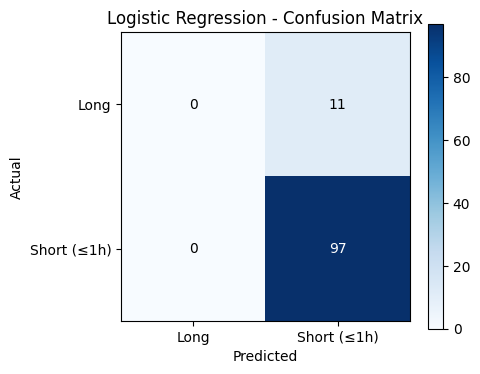

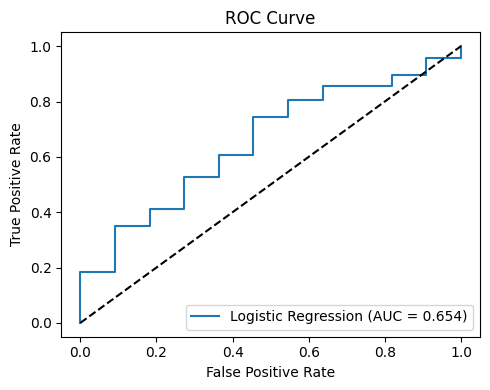


Logistic Regression Coefficients & Significance:
                   Feature   Coefficient    Std_Error  z_statistic      p_value  Significant
             rate_slope_1h  2.177113e+01 3.185851e+00     6.833695 8.275462e-12         True
avg_utilization_24h_before  1.474606e+01 3.500373e+00     4.212711 2.523240e-05         True
        num_spikes_last_7d  2.440813e-02 8.360221e-03     2.919556 3.505306e-03         True
      price_volatility_24h -8.839471e+01 4.071466e+01    -2.171078 2.992526e-02         True
       spread_to_base_rate -4.390439e+01 2.347841e+01    -1.869989 6.148528e-02        False
                top3_share  1.940638e+00 1.046268e+00     1.854819 6.362202e-02        False
                       hhi -2.705874e-01 1.472385e-01    -1.837749 6.609945e-02        False
           price_return_1h -2.603547e+02 1.630212e+02    -1.597060 1.102523e-01        False
     time_since_last_spike -1.447718e-06 1.033959e-06    -1.400169 1.614626e-01        False
      total_borrow_c

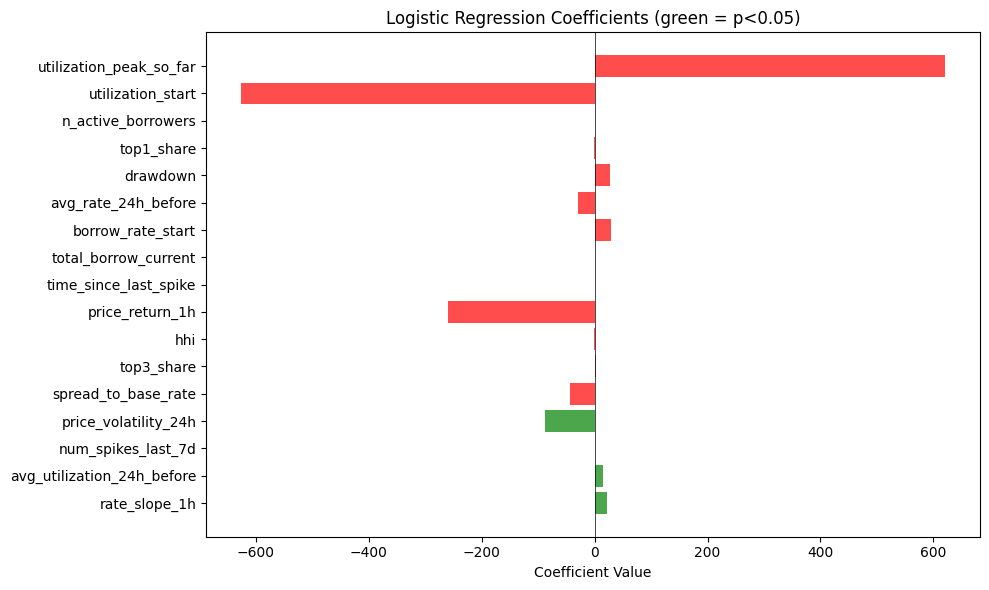


=== XGBoost Classifier (without Optuna) ===

XGBoost Classifier Performance:
Accuracy:  0.9074
Precision: 0.9143
Recall:    0.9897
F1 Score:  0.9505
ROC AUC:   0.8529


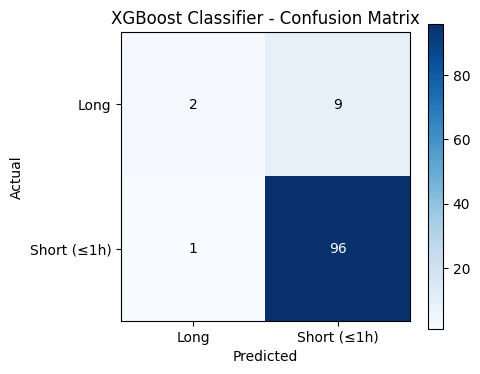

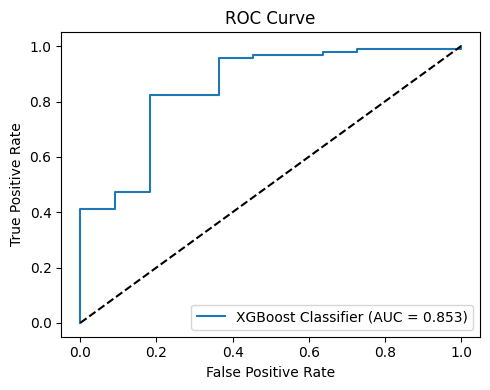


XGBoost Classifier Feature Importance:
                   Feature  Importance  Importance_pct
       spread_to_base_rate    0.093190        9.318995
             rate_slope_1h    0.092503        9.250307
      price_volatility_24h    0.081225        8.122534
   utilization_peak_so_far    0.073180        7.317992
                top3_share    0.072629        7.262907
        num_spikes_last_7d    0.072010        7.200972
avg_utilization_24h_before    0.069115        6.911474
         utilization_start    0.065705        6.570479
         borrow_rate_start    0.058510        5.851045
      total_borrow_current    0.050740        5.073969
                top1_share    0.049473        4.947271
       avg_rate_24h_before    0.041885        4.188453
        n_active_borrowers    0.041427        4.142730
     time_since_last_spike    0.040511        4.051097
           price_return_1h    0.037018        3.701823
                       hhi    0.036906        3.690615
                  drawdow

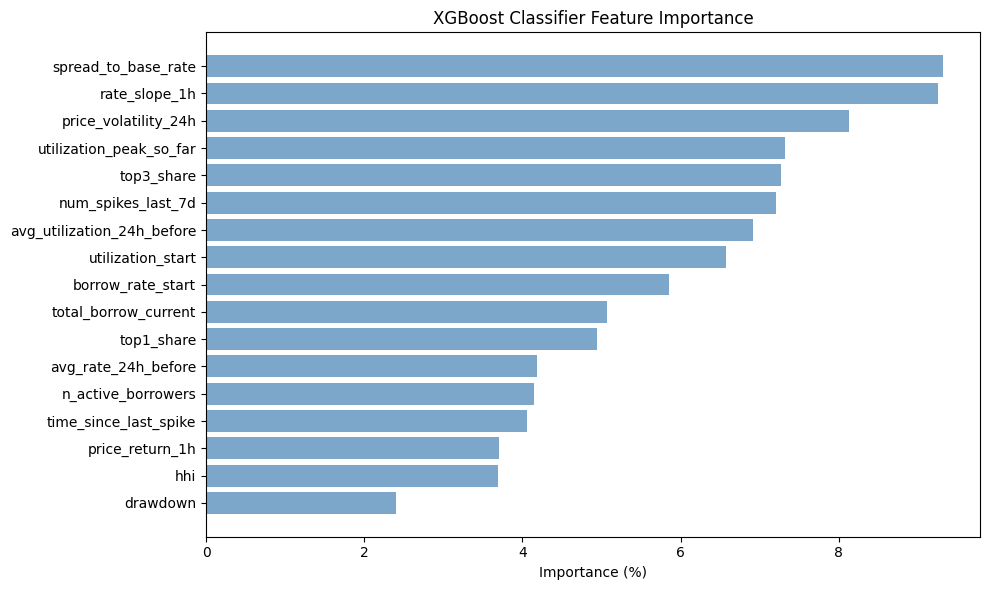

[I 2026-04-21 01:07:29,502] A new study created in memory with name: no-name-bda0179f-4e09-4fec-bb7f-a0897f6b30b1



=== XGBoost Classifier (with Optuna) ===


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-21 01:07:29,650] Trial 0 finished with value: 0.7741330834114339 and parameters: {'n_estimators': 267, 'max_depth': 4, 'learning_rate': 0.25489494092935905, 'subsample': 0.865739377873564, 'colsample_bytree': 0.9948896273484549, 'gamma': 3.9385315307838042, 'reg_alpha': 0.09649434177106901, 'reg_lambda': 7.123414440477937e-05}. Best is trial 0 with value: 0.7741330834114339.
[I 2026-04-21 01:07:29,760] Trial 1 finished with value: 0.8294283036551078 and parameters: {'n_estimators': 172, 'max_depth': 4, 'learning_rate': 0.09025885128363613, 'subsample': 0.8044378168618145, 'colsample_bytree': 0.8587485724219915, 'gamma': 2.8821488374644617, 'reg_alpha': 8.889524545257291e-05, 'reg_lambda': 4.163217858306597e-05}. Best is trial 1 with value: 0.8294283036551078.
[I 2026-04-21 01:07:29,910] Trial 2 finished with value: 0.796626054358013 and parameters: {'n_estimators': 226, 'max_depth': 3, 'learning_rate': 0.02155321787948871, 'subsample': 0.9865553595152946, 'colsample_bytree':

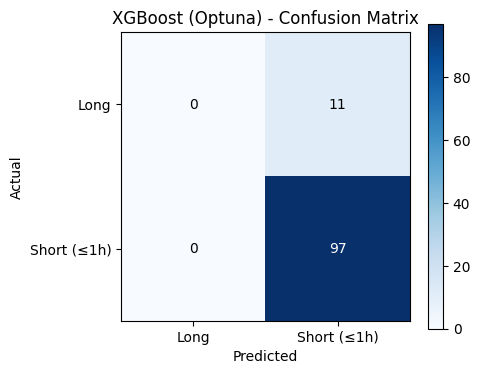

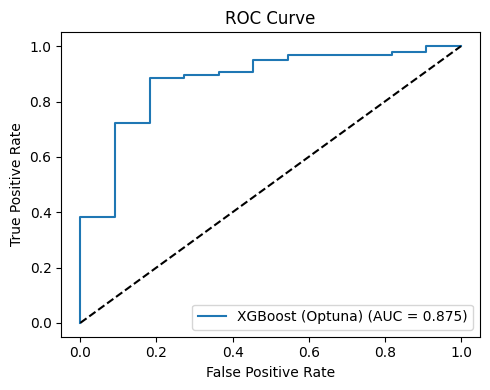

In [49]:
X_cls, y_cls, df_spikes_cls = prepare_classification_dataset(df, threshold_minutes=60)

X_train_c, X_val_c, X_test_c, y_train_c, y_val_c, y_test_c = split_data(
    X_cls, y_cls, test_size=0.2, val_size=0.1, random_state=42
)

print("\n=== Logistic Regression ===")
lr_cls, lr_train_pred, lr_train_proba, lr_val_pred, lr_val_proba = train_logistic_regression(
    X_train_c, y_train_c, X_val_c, y_val_c
)
lr_cls_metrics = evaluate_classification(y_val_c, lr_val_pred, lr_val_proba, "Logistic Regression")
lr_coef = report_logistic_coefficients(lr_cls, X_cls.columns.tolist(), X_train_c, y_train_c)

print("\n=== XGBoost Classifier (without Optuna) ===")
xgb_cls, xgb_train_pred, xgb_train_proba, xgb_val_pred, xgb_val_proba = train_xgboost_classifier(
    X_train_c, y_train_c, X_val_c, y_val_c, use_optuna=False
)
xgb_metrics = evaluate_classification(y_val_c, xgb_val_pred, xgb_val_proba, "XGBoost Classifier")
xgb_imp = report_xgboost_classifier_importance(xgb_cls, X_cls.columns.tolist())

print("\n=== XGBoost Classifier (with Optuna) ===")
xgb_opt, _, _, xgb_opt_val_pred, xgb_opt_val_proba = train_xgboost_classifier(
    X_train_c, y_train_c, X_val_c, y_val_c, use_optuna=True, n_trials=30
)
opt_metrics = evaluate_classification(y_val_c, xgb_opt_val_pred, xgb_opt_val_proba, "XGBoost (Optuna)")

### **Hazard modeling (bins)**

In [50]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from lifelines.utils import concordance_index

BINS_MINUTES = [0, 30, 60, 1440]
BIN_LABELS = []
for i in range(len(BINS_MINUTES)-1): BIN_LABELS.append(f"{BINS_MINUTES[i-1]}-{BINS_MINUTES[i]}m")

def prepare_hazard_dataset(df_long, bins=BINS_MINUTES):
    df = df_long.copy()
    df['duration_minutes'] = df['spike_duration_seconds'] / 60.0
    df['bin_start'] = np.nan
    df['bin_end'] = np.nan
    df['bin_label'] = ''
    df['event'] = 0

    rows = []
    for spike_idx, group in df.groupby('spike_index'):
        group = group.sort_values('time_offset_minutes')
        duration = group['duration_minutes'].iloc[0]
        for i in range(len(bins) - 1):
            bin_start = bins[i]
            bin_end = bins[i + 1]
            mask_bin_start = group['time_offset_minutes'] == bin_start
            if not mask_bin_start.any():
                continue
            row_at_start = group[mask_bin_start].iloc[0]
            event = 1 if (duration > bin_start and duration <= bin_end) else 0
            row_at_start = row_at_start.copy()
            row_at_start['bin_start'] = bin_start
            row_at_start['bin_end'] = bin_end
            row_at_start['bin_label'] = f"{bin_start}-{bin_end}m"
            row_at_start['event'] = event
            rows.append(row_at_start)
            if event == 1 or duration <= bin_start:
                break

    hazard_df = pd.DataFrame(rows)
    return hazard_df

def train_hazard_model(X_train, y_train):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    return model

def evaluate_hazard_model(model, X_val, y_val, hazard_val):
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_proba)
    brier = brier_score_loss(y_val, y_pred_proba)
    c_index = concordance_index(hazard_val['duration_minutes'], -y_pred_proba, y_val)
    print(f"Validation AUC: {auc:.4f}")
    print(f"Validation Brier Score: {brier:.4f}")
    print(f"Concordance Index: {c_index:.4f}")

    bin_brier = {}
    for bin_label in hazard_val['bin_label'].unique():
        mask = hazard_val['bin_label'] == bin_label
        if mask.sum() > 0:
            bin_brier[bin_label] = brier_score_loss(y_val[mask], y_pred_proba[mask])
    print("\nBrier Score per bin:")
    for bin_label, score in bin_brier.items():
        print(f"{bin_label}: {score:.4f}")

    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f'LogReg (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Hazard Model')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return y_pred_proba

def plot_calibration(y_true, y_pred_proba, n_bins=10):
    from sklearn.calibration import calibration_curve
    prob_true, prob_pred = calibration_curve(y_true, y_pred_proba, n_bins=n_bins)
    plt.figure(figsize=(5,4))
    plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression')
    plt.plot([0,1],[0,1],'k--', label='Perfectly calibrated')
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Fraction of positives')
    plt.title('Calibration Plot')
    plt.legend()
    plt.tight_layout()
    plt.show()

def predict_survival_curve(model, X_spike_start, bins=BINS_MINUTES):
    bin_starts = bins[:-1]
    pred_probs = []
    X_repeated = pd.DataFrame(np.repeat(X_spike_start.values, len(bin_starts), axis=0), columns=X_spike_start.columns)
    prob_event = model.predict_proba(X_repeated)[:, 1]
    surv = [1.0]
    for i, p in enumerate(prob_event):
        surv.append(surv[-1] * (1 - p))
    return np.array(bins), np.array(surv)

def plot_survival_examples_grid(model, X_val, hazard_val, n_examples=5, bins=BINS_MINUTES):
    unique_spikes = hazard_val[['spike_index', 'duration_minutes']].drop_duplicates()
    sample_spikes = unique_spikes.sample(n=min(n_examples, len(unique_spikes)), random_state=42)
    
    fig, axes = plt.subplots(1, n_examples, figsize=(4*n_examples, 4))
    if n_examples == 1:
        axes = [axes]
    
    for i, (_, spike_row) in enumerate(sample_spikes.iterrows()):
        spike_idx = spike_row['spike_index']
        true_duration = spike_row['duration_minutes']
        mask = hazard_val['spike_index'] == spike_idx
        X_spike = X_val.loc[mask].iloc[[0]]
        
        times, surv = predict_survival_curve(model, X_spike, bins)
        
        ax = axes[i]
        ax.step(times, surv, where='post', linewidth=2)
        ax.axvline(x=true_duration, color='red', linestyle='--', linewidth=1.5, label=f'True: {true_duration:.0f}m')
        ax.set_xlabel('Time (minutes)')
        ax.set_ylabel('Survival probability')
        ax.set_title(f'Spike {spike_idx}')
        ax.legend(loc='lower left')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1.05)
    
    plt.suptitle('Survival Curves - Random Spike Examples', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_kaplan_meier_style_comparison(model, X_val, hazard_val, bins=BINS_MINUTES, n_bootstrap=100):
    from sklearn.utils import resample
    
    unique_spikes = hazard_val.groupby('spike_index').first().reset_index()
    true_durations = unique_spikes['duration_minutes'].values
    
    pred_durations = []
    for idx, row in unique_spikes.iterrows():
        mask = hazard_val['spike_index'] == row['spike_index']
        X_spike = X_val.loc[mask].iloc[[0]]
        pred_durations.append(predict_expected_duration(model, X_spike, bins))
    pred_durations = np.array(pred_durations)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(true_durations, pred_durations, alpha=0.6, edgecolors='k', linewidth=0.5)
    max_val = max(true_durations.max(), pred_durations.max())
    plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
    plt.xlabel('Actual duration (minutes)')
    plt.ylabel('Predicted expected duration (minutes)')
    plt.title('Actual vs Predicted Expected Duration')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    mae = np.mean(np.abs(true_durations - pred_durations))
    print(f"MAE of expected duration: {mae:.2f} minutes")

def predict_expected_duration(model, X_spike, bins=BINS_MINUTES):
    times, surv = predict_survival_curve(model, X_spike, bins)
    expected_duration = 0
    for i in range(len(times) - 1):
        expected_duration += surv[i] * (times[i+1] - times[i])
    return expected_duration


Validation AUC: 0.6518
Validation Brier Score: 0.1880
Concordance Index: 0.6202

Brier Score per bin:
0-30m: 0.1777
30-60m: 0.2856
60-1440m: 0.1063


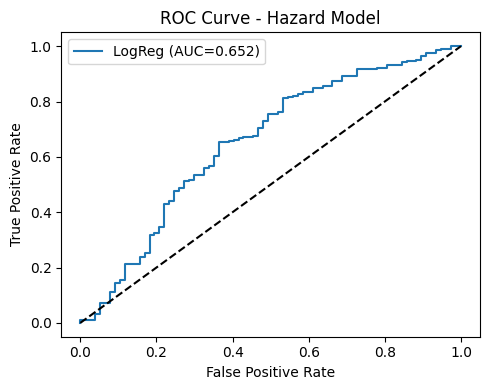

Validation AUC: 0.6250
Validation Brier Score: 0.1784
Concordance Index: 0.6074

Brier Score per bin:
0-30m: 0.1674
60-1440m: 0.0966
30-60m: 0.2616


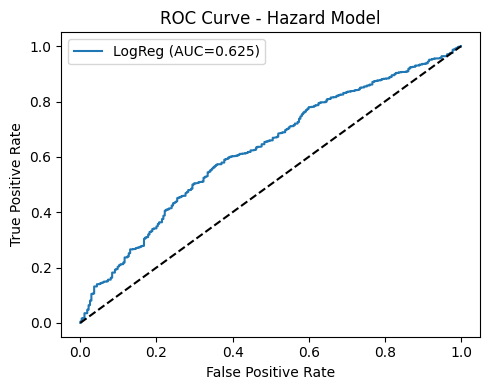

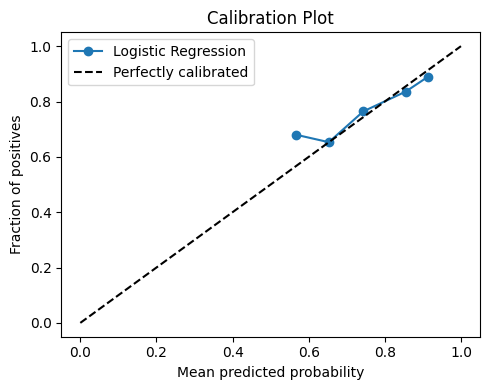

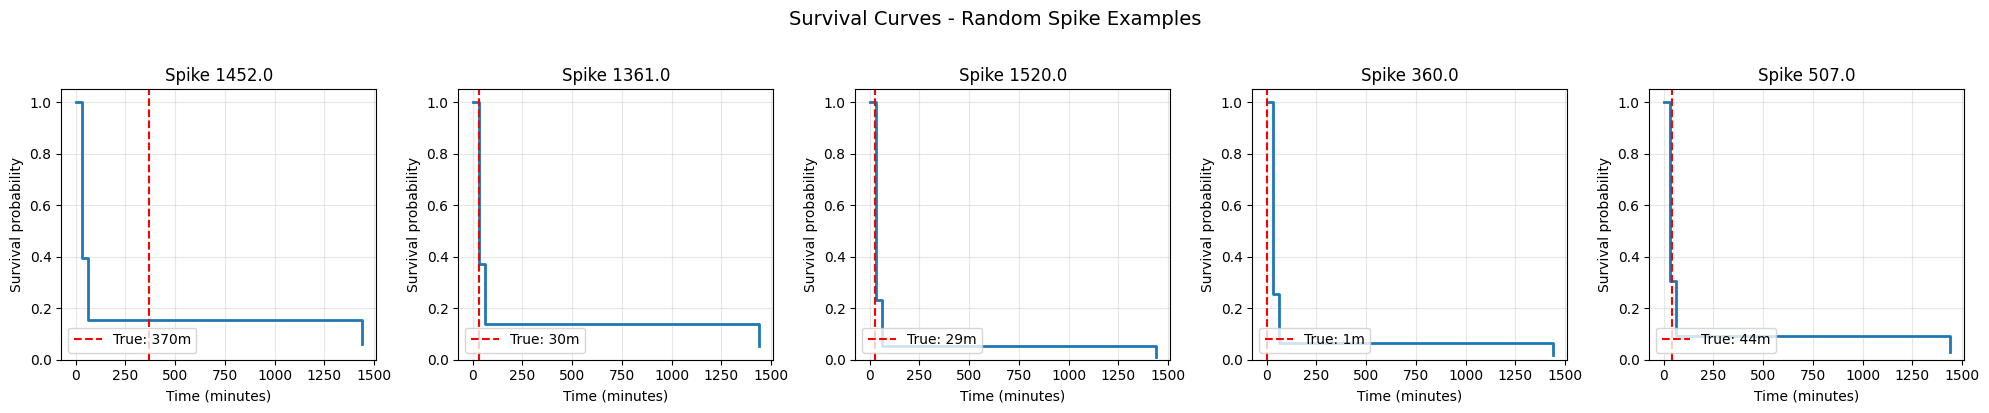

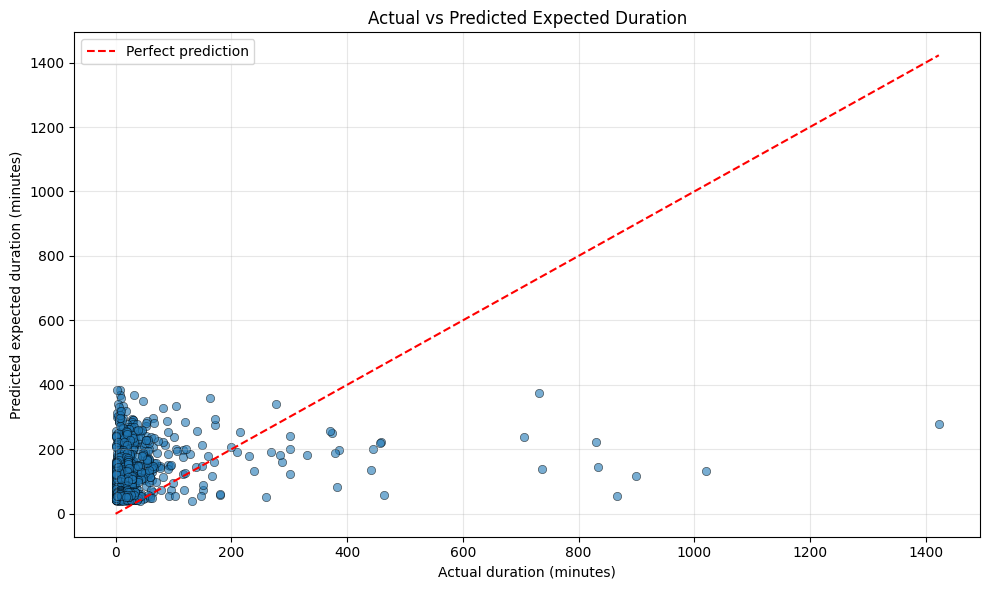

MAE of expected duration: 115.10 minutes


In [53]:
hazard_df = prepare_hazard_dataset(df, bins=BINS_MINUTES)

feature_cols = [
    'utilization_start', 'utilization_peak_so_far', 'borrow_rate_start',
    'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
    'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
    'price_return_1h', 'price_volatility_24h', 'drawdown',
    'avg_utilization_24h_before', 'avg_rate_24h_before',
    'num_spikes_last_7d', 'time_since_last_spike'
]
X = hazard_df[feature_cols].fillna(0)
y = hazard_df['event']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
val_idx = X_val.index
hazard_val = hazard_df.loc[val_idx]
hazard_train = hazard_df.loc[X_train.index]

model = train_hazard_model(X_train, y_train)
y_pred_proba = evaluate_hazard_model(model, X_val, y_val, hazard_val)
y_pred_proba_train = evaluate_hazard_model(model, X_train, y_train, hazard_train)


# plot_calibration(y_val, y_pred_proba)
plot_calibration(y_train, y_pred_proba_train)

plot_survival_examples_grid(model, X_val, hazard_val, n_examples=5, bins=BINS_MINUTES)
# plot_kaplan_meier_style_comparison(model, X_val, hazard_val, bins=BINS_MINUTES)
plot_kaplan_meier_style_comparison(model, X_train, hazard_train, bins=BINS_MINUTES)
